In [49]:
from veripulse.pulse import PulseConfig, PulseResult
import re
import json
import numpy as np
from pathlib import Path
from typing import Optional
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
%matplotlib inline

In [195]:
# data folder
data_dir = Path.cwd().parent/"data"

# file naming pattern
_PATTERN = re.compile(
    r"^(?P<method>[^_]+)_p(?P<num_tslots>\d+)_det(?P<detuning>-?[\d.]+)_err(?P<drive_error>-?[\d.]+)-(?P<identification>.+)\.json$"
)

# parsers
def parse_filename(path: Path) -> Optional[dict]:
    m = _PATTERN.match(path.name)
    if not m:
        return None
    return {
        "path": path,
        "method": m.group("method"),
        "num_tslots": int(m.group("num_tslots")),
        "detuning": float(m.group("detuning")),
        "drive_error": float(m.group("drive_error")),
        "identification": m.group("identification"),
    }

def collect_files(
    directory: str | Path,
    method: Optional[str] = None,
    num_tslots: Optional[int] = None,
    detuning: Optional[float] = None,
    drive_error: Optional[float] = None,
    identification: Optional[str] = None,
    load: bool = False,
) -> list[dict]:
    results = []
    for path in sorted(Path(directory).glob("*.json")):
        meta = parse_filename(path)
        if meta is None:
            continue

        if method      is not None and meta["method"]      != method:              continue
        if num_tslots  is not None and meta["num_tslots"]  != num_tslots:          continue
        if detuning    is not None and f"{meta['detuning']:.2f}"    != f"{detuning:.2f}":    continue
        if drive_error is not None and f"{meta['drive_error']:.2f}" != f"{drive_error:.2f}": continue
        if identification is not None and meta["identification"] != identification: continue

        if load:
            with open(path) as f:
                meta["data"] = json.load(f)

        results.append(meta)

    return results


def plot_summary_property(
    summaries: dict,
    quantity: str,
    log_y: bool = False,
):
    fig, ax = plt.subplots(figsize=(6, 3))

    for label, summary in summaries.items():
        xs = np.array(sorted(summary.keys()))

        means, stds = [], []
        for x in xs:
            vals = np.array(summary[x][quantity], dtype=float)
            means.append(vals.mean())
            stds.append(vals.std())

        means = np.array(means)
        stds  = np.array(stds)

        line, = ax.plot(xs, means, lw=2.5, label=label)
        c = line.get_color()
        ax.fill_between(xs, means - stds, means + stds, alpha=0.18, color=c)

    if log_y:
        ax.set_yscale('log')

    ax.set_xlabel("x key")
    ax.set_ylabel(quantity)
    ax.set_title(quantity)
    ax.legend(frameon=False)
    ax.grid(True, linewidth=0.2, alpha=0.4)
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()


def plot_summary_properties(
    summaries: dict,
    quantities: list,
    log_y: bool = False,
    smearing: list = None,
):
    if smearing is None:
        smearing = [True] * len(quantities)

    STYLES = ['-', '--', ':', '-.']
    COLORS = plt.rcParams['axes.prop_cycle'].by_key()['color']
    method_colors = {label: COLORS[i] for i, label in enumerate(summaries)}

    fig, ax = plt.subplots(figsize=(7, 3))

    for quantity, ls, smear in zip(quantities, STYLES, smearing):
        for label, summary in summaries.items():
            xs = np.array(sorted(summary.keys()))
            means, stds = [], []
            for x in xs:
                vals = np.array(summary[x][quantity], dtype=float)
                means.append(vals.mean())
                stds.append(vals.std())
            means = np.array(means)
            stds  = np.array(stds)

            c = method_colors[label]
            ax.plot(xs, means, lw=2, ls=ls, color=c, label=f"{label} — {quantity}")
            if smear:
                ax.fill_between(xs, means - stds, means + stds, alpha=0.12, color=c)
    if log_y:
        ax.set_yscale('log')

    ax.set_xlabel("number of pulses")
    ax.legend(frameon=False, bbox_to_anchor=(1, 1), loc='upper left', borderaxespad=.3)
    ax.grid(True, linewidth=0.4, alpha=0.4)
    ax.spines[["top", "right"]].set_visible(True)
    plt.tight_layout()
    plt.show()

    
def summary_byslot(method, slots):
    summary = dict()
    for slot in slots: 
        summary[slot] = {'fid_ul': [], 'si': [], 'si_lb':[], 'cost': [], 'diff': []}
        runs = collect_files(data_dir, method=method, num_tslots=slot)
        for r in runs:
            res = PulseResult.load(r['path'])
            summary[slot]['fid_ul'].append(np.mean(res.err_ul_list)) 
            summary[slot]['cost'].append(np.mean(res.err_hs_list)) 
            summary[slot]['si_lb'].append(res.si_lb)
            summary[slot]['si'].append(res.si)
            summary[slot]['diff'].append(res.si_lb - res.si)
    return summary

In [181]:
slots = [40, 120]
summaries = dict()
summaries['GRAPE'] = summary_byslot("GRAPE", slots)
summaries['CRAB'] = summary_byslot('CRAB', slots)

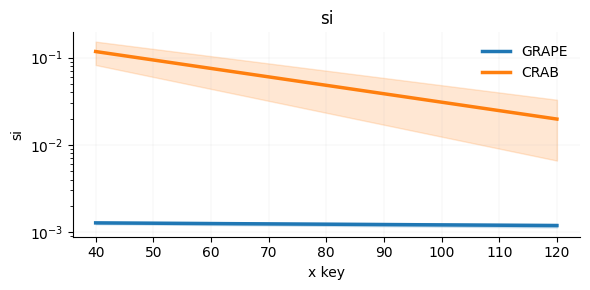

In [182]:
plot_summary_property(summaries = summaries, quantity='si', log_y=True)

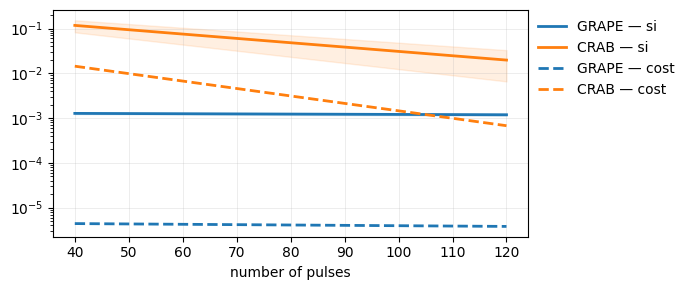

In [197]:
plot_summary_properties(
    summaries=summaries,
    quantities=['si', 'cost'],
    log_y=True,
    smearing = [True, False]
)